## Google Earth Engine
Google Earth Engine combines a multi-petabyte catalog of satellite imagery and geospatial datasets with planetary-scale analysis capabilities. Scientists, researchers, and developers use Earth Engine to detect changes, map trends, and quantify differences on the Earth's surface.   

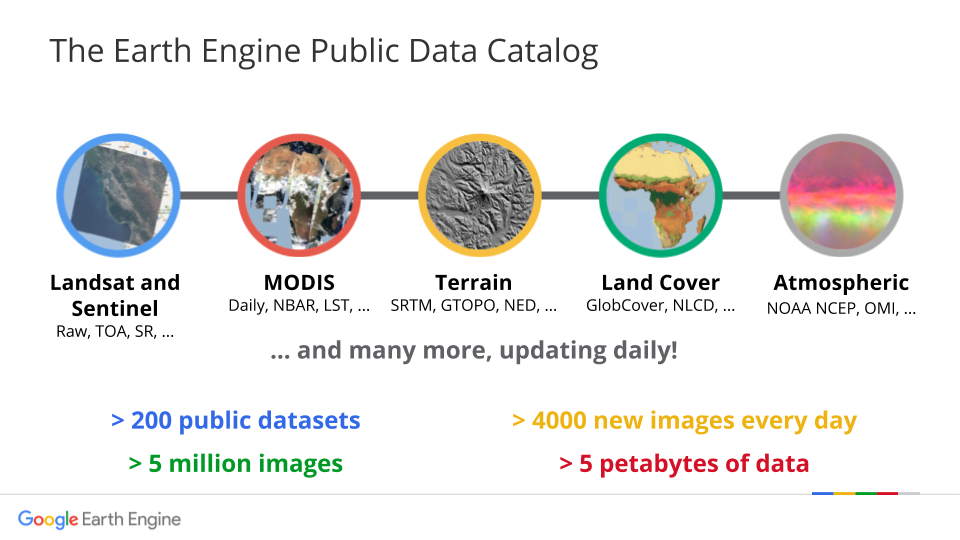  
Source: [geohackweek](https://geohackweek.github.io/GoogleEarthEngine/01-introduction/)

### What can you get from Google Earth Engine?
Nighttime light imagery after sunset from NOAA   
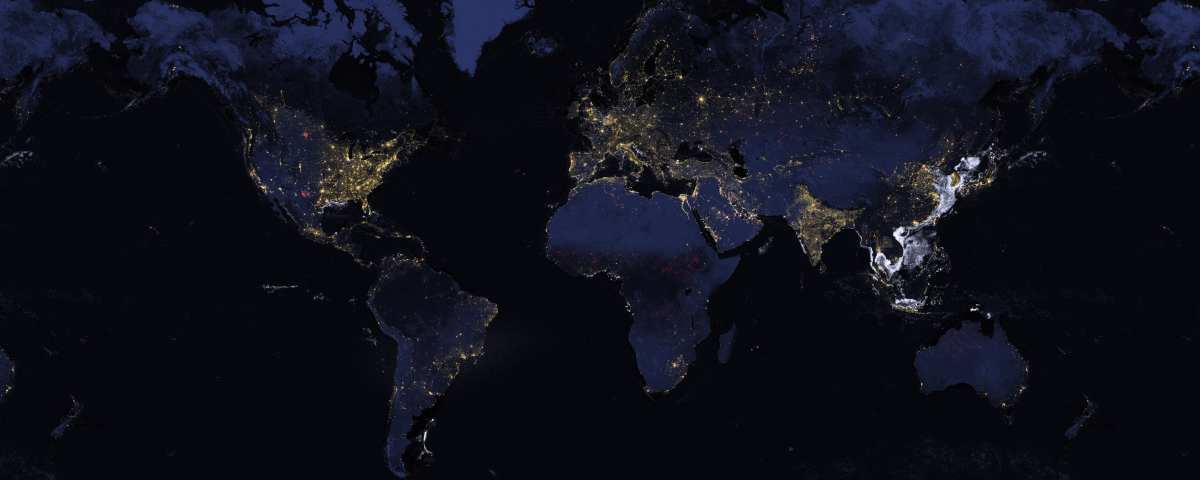   
Source: [NOAA](https://www.ncei.noaa.gov/news/sunset-nighttime-lights-noaa)

In [3]:
# Recommended installation:
#     pip install earthengine-api geemap xarray pandas matplotlib

# For data access and handling
import ee # earthengine-api
import xarray

# For plotting
import matplotlib.pyplot as plt
import pandas as pd
import geemap

### Initialize Google Earth Engine with API Key

[Google Earth Engine (GEE)](https://earthengine.google.com/) is a cloud-based platform
for planetary-scale geospatial analysis. All computation happens on Google's servers —
you don't download data, you send queries.

We authenticate using a **Service Account** (suitable for scripts and notebooks).
The credentials come from a JSON key file associated with the service account.  

Following are tutorials to Enable Earth Engine API and to Generate Google Earth Engine Service Account and json Key.  
-https://scribehow.com/viewer/1_Create_a_Google_Cloud_Project_and_Enable_Earth_Engine_API__oobJRoZcRoGYFZngARq2IQ   
-https://scribehow.com/viewer/2_Generate_Google_Earth_Engine_Service_Account_and_json_Key__SJPnajZQQCq-TU5hc0nT6g

In [ ]:
service_account = "PLEASE ENTER YOUR SERVICE ACCOUNT EMAIL" # client_email in json file
key_path        = "PLEASE ENTER THE PATH TO YOUR JSON KEY FILE" # json file path
credentials     = ee.ServiceAccountCredentials(service_account, key_path)

ee.Initialize(credentials)

In [ ]:
# 1. 定義感興趣的區域 (ROI) - 設定為台灣的 Bounding Box
roi = ee.Geometry.Rectangle([119.3, 21.8, 122.1, 25.4])

# 2. 詢問呼叫 NOAA VIIRS 夜間燈光 ImageCollection
viirs_collection = ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG")

# 3. 從 Collection 萃取單張 Image
# 這裡計算平均值來消除單月的雲層或雜訊干擾
nighttime_image = (
    viirs_collection
    .filterBounds(roi)                      # 空間篩選
    .filterDate('2023-01-01', '2023-12-31') # 時間篩選  取 2023 年全年的影像
    .select('avg_rad')                      # 指定「平均輻射亮度」波段
    .mean()                                 # 將多張影像降維成單張 ee.Image (取平均)
    .clip(roi)                              # 裁切邊界
)

# 4. 遮罩處理 (Masking) - 讓無光區變透明，只保留發光區域
light_mask = nighttime_image.gt(0.1)    # 輻射值小於 0.1 的區域視為無燈光（背景），將其 mask 掉
nighttime_image = nighttime_image.updateMask(light_mask)

# 5. 設定視覺化與地圖渲染
Map = geemap.Map(center=[23.6, 120.9], zoom=7)
Map.add_basemap('CartoDB.DarkMatter')

# 設定 顏色漸層：純黑 > 暗褐色 > 琥珀橘 > 金黃色 > 白光
vis_params = {
    'min': 1.0,
    'max': 60.0,
    'palette': ['050505', '4d2600', 'b35900', 'ff9900', 'ffdb4d', 'ffffff']
}

Map.addLayer(nighttime_image, vis_params, 'VIIRS 2023 Night Lights')

# 顯示地圖
Map